In [1]:
import torch
from tqdm.auto import tqdm

from point_e.diffusion.configs import DIFFUSION_CONFIGS, diffusion_from_config
from point_e.diffusion.sampler import PointCloudSampler
from point_e.models.download import load_checkpoint
from point_e.models.configs import MODEL_CONFIGS, model_from_config
from point_e.util.plotting import plot_point_cloud

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))

print('creating base model...')
base_name = 'base40M-textvec'
base_model = model_from_config(MODEL_CONFIGS[base_name], device)
base_model.eval()
base_diffusion = diffusion_from_config(DIFFUSION_CONFIGS[base_name])

print('creating upsample model...')
upsampler_model = model_from_config(MODEL_CONFIGS['upsample'], device)
upsampler_model.eval()
upsampler_diffusion = diffusion_from_config(DIFFUSION_CONFIGS['upsample'])

print('downloading base checkpoint...')
base_model.load_state_dict(load_checkpoint(base_name, device))

print('downloading upsampler checkpoint...')
upsampler_model.load_state_dict(load_checkpoint('upsample', device))

creating base model...
creating upsample model...
downloading base checkpoint...


  0%|          | 0.00/161M [00:00<?, ?iB/s]

downloading upsampler checkpoint...


<All keys matched successfully>

In [3]:
sampler = PointCloudSampler(
    device=device,
    models=[base_model, upsampler_model],
    diffusions=[base_diffusion, upsampler_diffusion],
    num_points=[1024, 4096 - 1024],
    aux_channels=['R', 'G', 'B'],
    guidance_scale=[3.0, 0.0],
    model_kwargs_key_filter=('texts', ''), # Do not condition the upsampler at all
)

In [11]:
# Set a prompt to condition on.
prompt = 'a h
# Produce a sample from the model.
samples = None
for x in tqdm(sampler.sample_batch_progressive(batch_size=1, model_kwargs=dict(texts=[prompt]))):
    samples = x

0it [00:00, ?it/s]

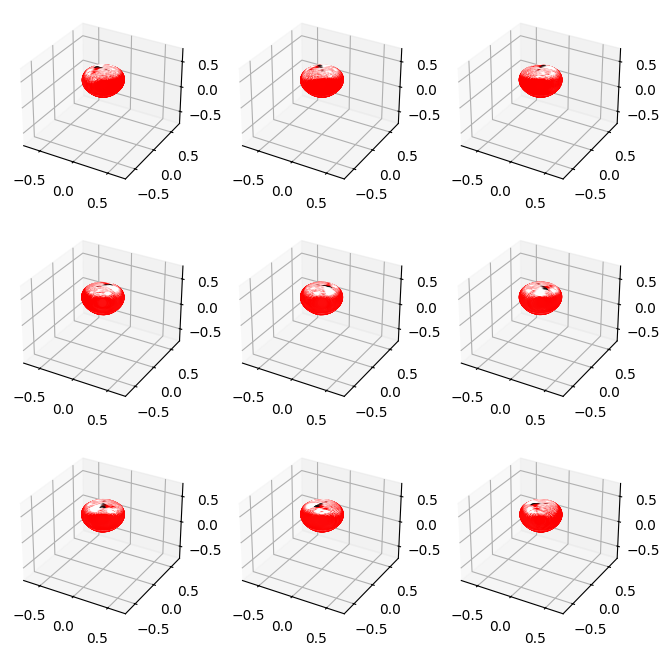

In [12]:
pc = sampler.output_to_point_clouds(samples)[0]
fig = plot_point_cloud(pc, grid_size=3, fixed_bounds=((-0.75, -0.75, -0.75),(0.75, 0.75, 0.75)))

In [13]:
import numpy as np
import os

# 1. 准备保存路径
# 注意：由于 Notebook 在 point-e 目录下运行，而 CLGLInterop 在上一级目录
save_dir = '/Users/binwen6/Lecture/3D计算机图形学/课程实验项目/Accelerated-Ray-Tracing-and-Enhanced-Marching-for-Integrated-flocking-with-point-cloudS/CLGLInterop/assets/point-cloud-300M'
os.makedirs(save_dir, exist_ok=True)

# 设置文件名（你可以根据 prompt 自定义文件名）
filename = f"{prompt.replace(' ', '_')}.npy"
save_path = os.path.join(save_dir, filename)

# 2. 提取并拼接特征 (x, y, z, r, g, b)
# pc.coords 是 (N, 3)，表示 x, y, z
# pc.channels['R'], ['G'], ['B'] 是 (N,)，需要 reshape 成 (N, 1) 然后拼接
pc_save = np.concatenate([
    pc.coords, 
    pc.channels['R'][:, None], 
    pc.channels['G'][:, None], 
    pc.channels['B'][:, None]
], axis=1)

# 3. 执行保存
np.save(save_path, pc_save)

print(f"点云已成功保存至: {save_path}")
print(f"数组形状为: {pc_save.shape}") # 应该是 (总点数, 6)


点云已成功保存至: /Users/binwen6/Lecture/3D计算机图形学/课程实验项目/Accelerated-Ray-Tracing-and-Enhanced-Marching-for-Integrated-flocking-with-point-cloudS/CLGLInterop/assets/point-cloud-300M/a_hot_air_balloon.npy
数组形状为: (4096, 6)
